# Week 2 EDA — LughaLink AI PSA Corpus

**Course:** DSA 4020 · **Deliverable:** cleaned dataset + EDA visuals  
**Input:** `datasets/processed/week2_cleaned_psas.csv` (from `scripts/prepare_week2_processing.py`)

This notebook covers domain distribution, text-length histograms, vocabulary size, and language-pair gaps.

In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
CLEANED = ROOT / "datasets" / "processed" / "week2_cleaned_psas.csv"
STATS = ROOT / "datasets" / "interim" / "week2_eda_stats.json"
FIG_DIR = ROOT / "datasets" / "interim" / "week2_eda_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CLEANED)
stats = json.loads(STATS.read_text(encoding="utf-8"))
print(f"rows={len(df):,}  domains={df['Domain'].nunique()}  vocab={stats['vocabulary_size']:,}")
df.head(2)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_lo

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_lo

AttributeError: _ARRAY_API not found

rows=4,149  domains=5  vocab=24,904


,PSA_ID,Domain,English,English_norm,Kiswahili,Kiswahili_norm,Target Languages,Source,Date,Metadata,...,code_switch,sw_cue_count,has_kiswahili,glossary_hits,glossary_hit_count,url_count,hashtag_count,mention_count,split,validation_subset
0,psa_2026_000001,Governance,PUBLIC NOTICE15th Jul 2026. The Commission rem...,PUBLIC NOTICE 15th Jul 2026. The Commission re...,NaN,NaN,"[""Dholuo"", ""Ekegusii"", ""Somali""]",https://www.iebc.or.ke/news/?PUBLIC_NOTICE,NaN,"{""contributor"": ""Iranzi Innocent / data/govern...",...,False,0,False,IEBC|KSh,2,1,4,1,test,False
1,psa_2026_000002,Governance,EVERY VOTE MATTERS. EVERY LAW MATTERS.15th Jul...,EVERY VOTE MATTERS. EVERY LAW MATTERS.15th Jul...,NaN,NaN,"[""Dholuo"", ""Ekegusii"", ""Somali""]",https://www.iebc.or.ke/news/?EVERY_VOTE_MATTER...,NaN,"{""contributor"": ""Iranzi Innocent / data/govern...",...,False,0,False,IEBC,1,1,4,1,train,False


## 1. Domain distribution

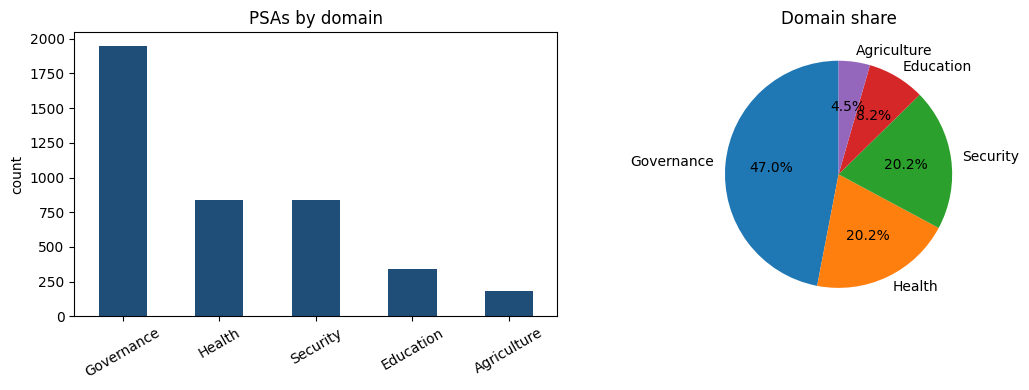

Domain
Governance     1949
Health          838
Security        837
Education       340
Agriculture     185
Name: count, dtype: int64

In [2]:
domain_counts = df["Domain"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
domain_counts.plot(kind="bar", ax=axes[0], color="#1f4e79", rot=30)
axes[0].set_title("PSAs by domain")
axes[0].set_ylabel("count")
axes[0].set_xlabel("")
axes[1].pie(domain_counts, labels=domain_counts.index, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Domain share")
plt.tight_layout()
fig.savefig(FIG_DIR / "domain_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
domain_counts

## 2. Text length histograms

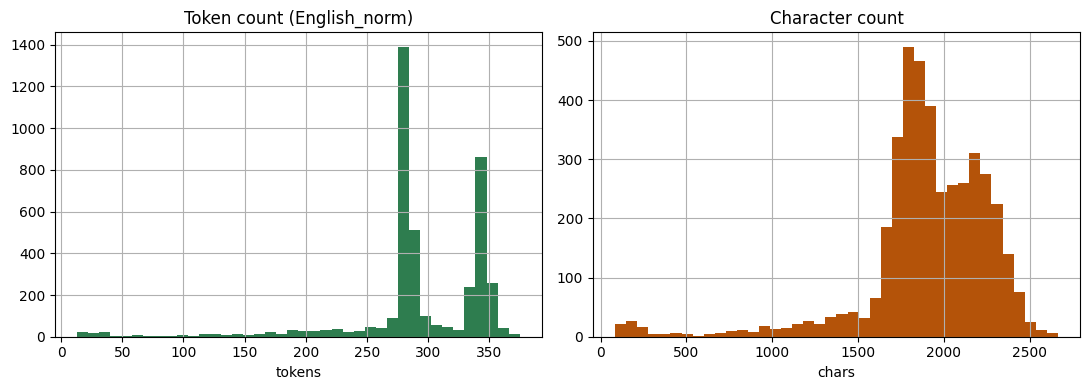

min        13.00
p25       279.00
median    285.00
p75       340.00
max       375.00
mean      291.43
dtype: float64

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df["token_count"].hist(bins=40, ax=axes[0], color="#2e7d4f")
axes[0].set_title("Token count (English_norm)")
axes[0].set_xlabel("tokens")
df["char_count"].hist(bins=40, ax=axes[1], color="#b45309")
axes[1].set_title("Character count")
axes[1].set_xlabel("chars")
plt.tight_layout()
fig.savefig(FIG_DIR / "length_histograms.png", dpi=150, bbox_inches="tight")
plt.show()
pd.Series(stats["token_count"])

## 3. Vocabulary & glossary

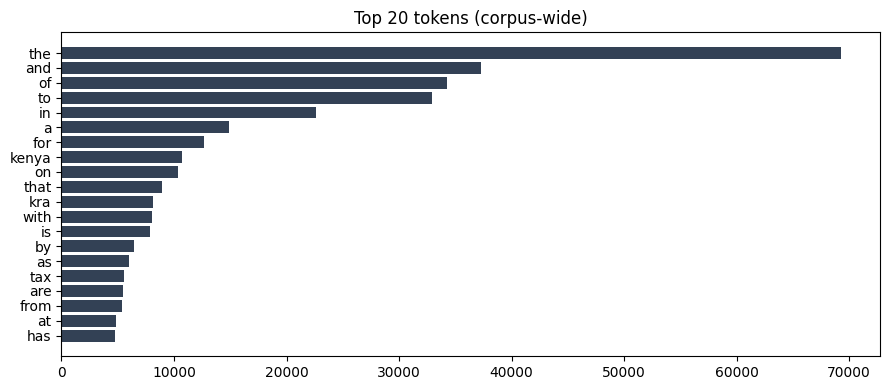

vocabulary_size: 24904
top glossary hits: [['KRA', 1125], ['county', 1063], ['KSh', 673], ['IEBC', 549], ['ward', 99], ['Huduma', 85], ['KUCCPS', 79], ['WASH', 66], ['EACC', 60], ['TVET', 41]]
code_switch_rows: 26


In [4]:
top_tokens = pd.DataFrame(stats["top_tokens"], columns=["token", "count"]).head(20)
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(top_tokens["token"][::-1], top_tokens["count"][::-1], color="#334155")
ax.set_title("Top 20 tokens (corpus-wide)")
plt.tight_layout()
fig.savefig(FIG_DIR / "top_tokens.png", dpi=150, bbox_inches="tight")
plt.show()

print("vocabulary_size:", stats["vocabulary_size"])
print("top glossary hits:", stats.get("top_glossary_hits", [])[:10])
print("code_switch_rows:", stats.get("code_switch_rows"))

## 4. Language-pair statistics & gaps

lang_primary:
en    4147
fr       2
dtype: int64

rows_with_kiswahili: 0
language_pair_notes:
{
  "en_psas": 4149,
  "en_sw_pairs_present": 0,
  "target_lang_placeholders": [
    "Dholuo",
    "Ekegusii",
    "Somali"
  ],
  "gap": "Almost all rows are English-only; EN\u2194SW harvest still required for true parallel stats."
}

splits:
split
train    3318
test      419
dev       412
Name: count, dtype: int64
native_validation_flagged_rows: 500


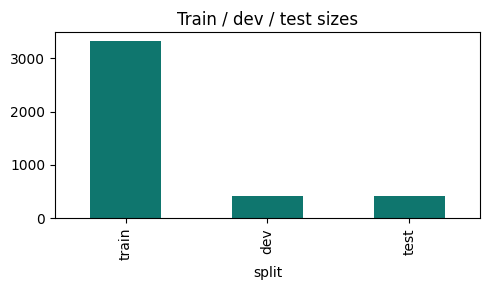

In [5]:
lang = pd.Series(stats.get("lang_primary", {}))
print("lang_primary:")
print(lang)
print("\nrows_with_kiswahili:", stats.get("rows_with_kiswahili"))
print("language_pair_notes:")
print(json.dumps(stats.get("language_pair_notes", {}), indent=2))

split_counts = df["split"].value_counts()
val_counts = df["validation_subset"].astype(str).str.lower().eq("true").sum()
print("\nsplits:")
print(split_counts)
print("native_validation_flagged_rows:", int(val_counts))

fig, ax = plt.subplots(figsize=(5, 3))
split_counts.reindex(["train", "dev", "test"]).plot(kind="bar", ax=ax, color="#0f766e")
ax.set_title("Train / dev / test sizes")
plt.tight_layout()
fig.savefig(FIG_DIR / "split_sizes.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Insights (fill into Week 2 report)

1. **Domain imbalance:** Governance dominates; Education and Agriculture are thin for modeling.
2. **Length:** Token counts cluster high (many long notices) — consider sentence-level splitting before MT.
3. **Parallel gap:** Almost no Kiswahili pairs in the cleaned English corpus; EN↔SW harvest is required for language-pair EDA / Week 3.
4. **Validation:** 500 stratified rows in `datasets/gold/native_validation_500.csv` await native-speaker review.
5. **Next:** glossary expansion + optional EN↔SW harvest, then NLLB seeding as Week 3 prep.